![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Jiale chen
- Estudiante n°2:

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis** (30%), **Construcción del Modelo** (40%) y **Despliegue del Modelo** (30%). Este notebook corresponde a la **Parte 2 - Construcción del Modelo**, y asume que ya completaste la **Parte 1 - Informe de Análisis**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Solo se evalúa **lo que implementas y respondes**; el **código y los recursos entregados no tienen puntaje**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Preparación** | 5 preguntas conceptuales (0.1 c/u) | 0.5 |
| **2 — Introducción a la Experimentación** | 3 preguntas (0.2 c/u) | 0.6 |
| **3 — Barrido de Combinaciones** | 10 experimentos (0.2 c/u) = 2.0 · preguntas LogReg 0.9 · Árbol/RF 0.2 · LightGBM 0.4 · MLP 0.4 | 3.9 |
| **4 — Selección del Mejor Modelo** | 5 preguntas (0.2 c/u) | 1.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

> El puntaje de cada pregunta y experimento aparece **inline** como `(0.X pts)`.

Esta nota corresponde a la nota de la **Parte 2** que equivale a un **40%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| **2 — Modelo**     | **40%**     |
| 3 — Despliegue     | 30%         |


## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 2 - Construcción del Modelo

En la Parte 1 entendiste el problema y exploraste los datos. Recapitulemos lo que ya sabemos y que guiará todo este notebook:

- El problema es de **clasificación multiclase**: predecir `Nivel_Prioridad` ∈ {`Baja`, `Media`, `Alta`, `Critica`}.
- Las clases están **desbalanceadas** (Media ~39%, Baja ~36%, Alta ~17%, Critica ~7%).
- La variable `Tiempo_de_Resolución_Horas` es **data leakage** (no está disponible en inferencia), así que **no la usaremos**.
- Contamos con features de **texto** (`Asunto_Ticket`, `Contenido_Ticket`), **categóricas** (`Canal_Ticket`, `Categoría_Problema`), una **numérica** (`N_Caracteres_Ticket`) y los **embeddings** (`gemini-embedding-001`, 1024 dimensiones).
- Siguiendo la decisión de la Parte 1, la **métrica a optimizar será el _macro recall_** (promedio simple del recall por clase), para no descuidar a la clase `Critica`.

La idea de esta parte es experimentar con muchas combinaciones de **(features × modelo)**, optimizando los hiperparámetros con **Optuna** y registrando todo en **MLflow**, para finalmente elegir y exportar el mejor.

> **MLflow**: usaremos MLflow para *experiment tracking*. Como MLflow 3.x deprecó el backend de archivos, usaremos un backend de base de datos local (`sqlite:///mlflow.db`). Si no lo tienes instalado:
> ```bash
> uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk
> ```
> Para abrir la interfaz gráfica y comparar tus runs:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```

---

# Sección 1 - Preparación — (0.5 pts)

Antes de modelar, dejaremos listo el **protocolo experimental**: definir el split y la métrica y el ejecutor de experimentos antes de ejecutar cualquier experimento.

> Este código será dado, por ende, no tendrá puntaje.

Tareas de esta sección:

1. Importar librerías, configurar MLflow (tracking URI + experimento)., fijar semillas y definir las **constantes compartidas**.
2. Cargar `tickets.parquet` y `embeddings.parquet`. Descartar el *data leakage*, contruir una única columna de texto y armar un **único** dataframe `X_full` que contenga las features tabulares, el texto y las 1024 columnas de embedding.
3. Separar en **train / val / test (60/20/20) estratificado**.

In [ ]:
# ------------ 1. Importar librerías, fijar semillas y configurar constantes ------------

import re

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
experiment_name = "ProyectoMDS7202"

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name)

mlflow.set_experiment(experiment_name)

# Definir constantes y fijar semillas
SEED = 42

np.random.seed(SEED)

ORDEN_CLASES = ["Baja", "Media", "Alta", "Critica"]
NUM_COLS = ["N_Caracteres_Ticket"]
CAT_COLS = ["Canal_Ticket", "Categoría_Problema"]
TEXT_COL = "Texto"

# ------------ 2. Cargar y preprocesar los datos ------------

# Cargar datos tabulares
df = pd.read_parquet("data/tickets.parquet")

# Descartamos la variable con data leakage detectada en la Parte 1
df = df.drop(columns=["Tiempo_de_Resolución_Horas"])

# Combinar campos de texto en una sola columna "Texto"
df["Texto"] = df["Asunto_Ticket"].fillna("") + " " + df["Contenido_Ticket"].fillna("")

# Cargar Embeddings (mismo orden de filas que df).
embeddings = pd.read_parquet("data/embeddings.parquet")
EMBEDDING_COLS = list(embeddings.columns)

# Generar único dataframe con todas las variables: tabular + texto + embeddings.
X_full = pd.merge(
    df.drop(columns=["Nivel_Prioridad", "Asunto_Ticket", "Contenido_Ticket"]),
    embeddings,
    on="Id_Ticket",
).drop(columns=["Id_Ticket"])
y = df["Nivel_Prioridad"]

print("---------- EDA Breve ----------\n")
print("X_full:", X_full.shape, "| columnas de embedding:", len(EMBEDDING_COLS))
print("Clases:", sorted(y.unique()))
display(X_full.head(10))
display(y.head(10))
display((y.value_counts() / len(y)).mul(100).round(2).rename("Distribución Labels (%)", inplace=True))

---------- EDA Breve ----------

X_full: (2000, 1031) | columnas de embedding: 1024
Clases: ['Alta', 'Baja', 'Critica', 'Media']


,N_Caracteres_Ticket,Canal_Ticket,Categoría_Problema,Usuario-Tipo_de_Cuenta,Usuario-Antiguedad_Cuenta_Dias,Fecha_Envío,Texto,embedding_dim_1,embedding_dim_2,embedding_dim_3,...,embedding_dim_1015,embedding_dim_1016,embedding_dim_1017,embedding_dim_1018,embedding_dim_1019,embedding_dim_1020,embedding_dim_1021,embedding_dim_1022,embedding_dim_1023,embedding_dim_1024
0,531,Whatsapp,Cuenta,Premium,159,2024-01-02,Error al iniciar sesión en nuevo celular por d...,-0.011585,-0.008728,0.012878,...,-0.011539,-0.016249,0.004422,-0.022274,0.004511,0.001428,-0.007812,-0.020485,-0.001888,-0.000408
1,784,Whatsapp,Otro,Premium,192,2024-01-02,Error al actualizar correo electrónico: bloque...,0.014494,0.004070,0.011298,...,-0.019967,-0.008424,-0.002084,-0.002761,-0.004148,-0.007131,-0.012717,-0.019045,-0.015172,0.004308
2,600,Whatsapp,Fraude,Free,314,2024-01-02,Cobro desconocido en mi tarjeta digital Hola b...,-0.010936,0.020796,0.011680,...,-0.021763,-0.007094,-0.011453,-0.001084,-0.005820,-0.015085,0.003200,-0.019789,-0.018502,-0.001085
3,659,Whatsapp,Cuenta,Free,228,2024-01-02,"Cuenta bloqueada sin aviso, necesito ayuda urg...",0.003248,0.005420,0.003422,...,-0.019830,-0.007490,-0.013525,0.000086,-0.011983,0.007148,-0.002536,-0.016200,-0.003927,-0.004028
4,853,Whatsapp,Otro,Free,72,2024-01-03,Me descontaron plata del cajero y no salió el ...,-0.010437,0.013634,0.009859,...,-0.006401,-0.001971,0.002344,-0.010598,-0.011034,-0.012039,-0.000857,-0.009420,-0.006597,0.012463
5,672,Whatsapp,Otro,Free,71,2024-01-03,Problemas con retiro en cajero y saldo retenid...,-0.006699,0.015320,0.004916,...,-0.002004,-0.009383,0.002027,-0.004618,-0.005886,0.001436,-0.002760,-0.010959,-0.019190,0.013137
6,691,Correo,Cuenta,Free,27,2024-01-03,Problema con transferencia no recibida: dinero...,-0.001424,0.013316,-0.001574,...,-0.017849,0.000331,-0.004115,-0.007396,-0.016886,-0.004226,0.000309,-0.011096,-0.009890,0.001992
7,782,Whatsapp,Técnica,Free,193,2024-01-05,Error al acceder a la sección de inversiones (...,-0.001278,0.014927,0.002564,...,-0.021633,-0.006482,0.000185,-0.000037,-0.001324,-0.010792,0.003312,-0.020291,-0.002917,-0.004307
8,652,Página Web,Técnica,Free,283,2024-01-05,"Error en transferencia y saldo descontado, ayu...",0.003861,-0.008191,0.009408,...,-0.009119,-0.002006,0.003867,-0.010697,-0.020366,-0.003357,0.003855,-0.027547,-0.014218,0.010238
9,427,Whatsapp,Pregunta general,Free,72,2024-01-05,duda con inversiones y error en la app hola bu...,-0.010484,0.003417,0.022390,...,-0.016919,-0.004394,-0.004335,-0.009940,0.002788,-0.003919,0.001589,-0.023548,-0.008324,-0.010632


0     Baja
1    Media
2     Baja
3    Media
4    Media
5    Media
6    Media
7    Media
8    Media
9     Baja
Name: Nivel_Prioridad, dtype: object

Nivel_Prioridad
Media      39.45
Baja       36.15
Alta       17.50
Critica     6.90
Name: Distribución Labels (%), dtype: float64

In [2]:
# ------------ 3. Split train/val/test ------------

print("---------- Splits ----------\n")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_full,
    y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=SEED,
)

print("Elementos por set | Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
d_y_train = (
    (y_train.value_counts() / len(y_train)).mul(100).round(2).rename("Distribución Labels Train (%)", inplace=True)
)
d_y_val = (y_val.value_counts() / len(y_val)).mul(100).round(2).rename("Distribución Labels Val (%)", inplace=True)
d_y_test = (y_test.value_counts() / len(y_test)).mul(100).round(2).rename("Distribución Labels Test (%)", inplace=True)
display(pd.concat([d_y_train, d_y_val, d_y_test], axis=1))

---------- Splits ----------

Elementos por set | Train: 1200 | Val: 400 | Test: 400


,Distribución Labels Train (%),Distribución Labels Val (%),Distribución Labels Test (%)
Nivel_Prioridad,,,
Media,39.42,39.5,39.50
Baja,36.17,36.0,36.25
Alta,17.50,17.5,17.50
Critica,6.92,7.0,6.75


Antes de modelar, responde:

1. ¿Por qué fijamos el split (train/val/test) **antes** de entrenar cualquier modelo? ¿Qué riesgo evitamos? **(0.1 pts)**
2. En general, siempre vamos a utilizar el enfoque de optimización de hiperparámetros. ¿Por qué utilizar train/val/test y no solo train/test es importante? ¿Qué otra técnica hay para evitar esto? **(0.1 pts)**
3. ¿Por qué usamos un split **estratificado**? ¿qué problema causaría un split aleatorio en val/test asumiendo que para esta cantidad de datos, la métricas pueden ser ruidosas? Apoya tu respuesta ejecutando el bloque `Split train/val/test` de la celda anterior comentando el parámetro `stratify` y justifica usando los resultados obtenidos. Luego, recuerda volver a agregar el parámetro, de lo contrario, tus resultados se podrían ver afectados. **(0.1 pts)**
4. ¿Por qué la métrica adecuada aquí es el **macro recall** y no, por ejemplo, el _accuracy_? Conéctalo con el desbalance y con lo que respondiste en la Parte 1. **(0.1 pts)**
5. ¿Qué es el **experiment tracking** y qué ganamos al registrar cada modelo en MLflow en lugar de solo imprimir métricas? Piensa en qué pasa si reinicias, por ejemplo, el notebook de Jupyter. **(0.1 pts)**

_Subtotal preguntas: 0.5 pts_

**Responde aquí**

> 
1- Fijamos el split `train/val/test` antes de entrenar cualquier modelo para asegurar que todos los experimentos se evalúen bajo las mismas condiciones. Así, las comparaciones entre modelos, features e hiperparámetros son justas, porque todos usan los mismos datos de entrenamiento, validación y prueba.

El principal riesgo que evitamos es el **data leakage** o contaminación de la evaluación. Si el split cambiara entre experimentos, podríamos elegir un modelo porque tuvo suerte con una partición más fácil y no porque realmente generaliza mejor. Además, mantener un conjunto de test separado hasta el final permite estimar de forma más realista el desempeño del modelo en datos nuevos.

2- Usar `train/val/test` es importante porque, al optimizar hiperparámetros, necesitamos un conjunto de **validación** para comparar configuraciones y elegir el mejor modelo sin tocar el conjunto de prueba. Si usáramos solo `train/test`, terminaríamos tomando decisiones en base al desempeño en test, por lo que el test dejaría de ser una evaluación final independiente y el resultado podría quedar sobreajustado a ese conjunto.

El riesgo que se evita es el **sobreajuste al conjunto de test** durante la selección de hiperparámetros. Para evitar esto también se puede usar **validación cruzada**, donde el entrenamiento y la validación se repiten en distintas particiones de los datos, obteniendo una estimación más robusta del desempeño del modelo.

3- Usamos un split **estratificado** porque las clases están desbalanceadas, especialmente `Critica`, que representa una proporción pequeña del dataset. La estratificación permite que `train`, `val` y `test` mantengan proporciones similares de `Baja`, `Media`, `Alta` y `Critica`, haciendo que la evaluación sea más estable y representativa.

Si se usara un split aleatorio sin `stratify`, podría ocurrir que `val` o `test` quedaran con muy pocos casos de `Critica` o `Alta`. Como la métrica principal es **macro recall**, esto sería problemático, porque el recall de cada clase tiene el mismo peso en el promedio. Con pocos ejemplos, una o dos predicciones correctas o incorrectas podrían cambiar mucho la métrica, generando resultados ruidosos.

Al ejecutar el split sin `stratify`, se debería observar que las proporciones de clases varían más entre los conjuntos, sobre todo en las clases minoritarias. Por eso, se debe volver a usar `stratify=y` y `stratify=y_tmp`, para evitar que los resultados del modelo dependan demasiado de una partición aleatoria poco representativa.

4- La métrica adecuada es **macro recall** porque el problema tiene clases desbalanceadas y el negocio necesita detectar bien todas las prioridades, especialmente las más críticas. En este dataset, `Media` y `Baja` concentran la mayoría de los casos, mientras que `Critica` representa una proporción mucho menor. Por eso, un modelo podría obtener un buen **accuracy** prediciendo correctamente las clases mayoritarias, pero fallar en identificar tickets `Alta` o `Critica`.

El **macro recall** calcula el recall de cada clase por separado y luego los promedia dando el mismo peso a todas las clases. Esto es importante porque obliga a evaluar si el modelo está detectando correctamente también las clases minoritarias. En particular, se conecta con lo respondido en la Parte 1: para ChaucherApp es más grave no detectar un ticket `Critica` que equivocarse en una clase frecuente, porque podría retrasar la atención de problemas urgentes.

Por lo tanto, `accuracy` podría ocultar errores importantes en las clases minoritarias, mientras que **macro recall** permite medir mejor si el modelo cumple el objetivo de no descuidar prioridades urgentes.

5- El **experiment tracking** consiste en registrar de forma ordenada los experimentos realizados, incluyendo el modelo usado, sus hiperparámetros, las features utilizadas, las métricas obtenidas y, eventualmente, los artefactos generados.

Registrar cada modelo en **MLflow** es mejor que solo imprimir métricas porque los resultados quedan guardados y se pueden comparar después, incluso si se reinicia el notebook de Jupyter. Si solo imprimimos métricas, esa información se puede perder al cerrar o reiniciar la sesión. En cambio, MLflow permite recuperar los runs, comparar modelos, revisar configuraciones anteriores y elegir el mejor experimento de forma trazable y reproducible.

---

# Sección 2 - Introducción a la Experimentación — (0.6 pts)

La idea de la experimentación de este lab es que puedan probar muchas combinaciones de modelos y subconjuntos de features para resolver el problema.
Para no repetir el código de `Optuna` + `MLflow` una y otra vez, encapsularemos todo en **dos clases (ejecutor de experimentos y experimento abstracto) las cuales se te serán provistas**.

La idea de esta abstracción es finalmente que ustedes no definan el cómo ejecutan el experimento (código muy estándar), si no que simplemente definan la pipeline y el espacio de hiperparámetros a probar. 

- **`AbstractExperiment`**: define el *contrato* de un experimento. Cada experimento que ustedes hagan debe ser una **subclase** que implemente estos 4 métodos:
  - `model_name` (propiedad): Nombre del modelo a probar. Sirve para identificar el run.
  - `feature_set` (propiedad): Subconjunto de features a utilizar. Sirve para identificar el run.
  - `build_pipeline(hparams) -> Pipeline`: construye tu `ColumnTransformer` + modelo, parametrizado por `hparams`.
  - `generate_trial_hparams(trial) -> dict`: define el espacio de búsqueda de Optuna.
  
Mas adelante habrá un ejemplo de cómo implementar esto.

- **`ExperimentExecutor`**: recibe un experimento y se encarga del resto: corre **Optuna** (optimizando macro recall en **val**, cada *trial* como run anidado en MLflow), reentrena la mejor configuración con **train+val** y la evalúa en **test**, registrando todo en MLflow.

Esto nos garantiza que todos los modelos se comparen con el mismo protocolo.

In [3]:
import abc

import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
from optuna.integration.mlflow import MLflowCallback
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    recall_score,
)
from sklearn.pipeline import Pipeline


class AbstractExperiment(abc.ABC):
    """Experimento Abstracto.

    Permite que más adelante definan los experimentos a ejecutar.
    """

    @property
    @abc.abstractmethod
    def model_name(self) -> str:
        """Nombre del modelo, p.ej. 'Regresión_Logística', 'Arbol_de_Decision', 'LightGBM'..."""
        raise NotImplementedError()

    @property
    @abc.abstractmethod
    def feature_set(self) -> str:
        """Identificador del conjunto de features: 'Base', 'BoW', 'Embeddings', 'Todo', ..."""
        raise NotImplementedError()

    @property
    def study_name(self) -> str:
        """Identidad única de la combinación modelo × features. - Esta no debe ser redefinida"""
        return f"{self.model_name}__{self.feature_set}"

    @abc.abstractmethod
    def build_pipeline(self, hparams: dict) -> Pipeline:
        """Construye la pipeline a partir de los hiperparámetros entregados por Optuna.

        En este método deberán generar tanto el ColumnTransformer, como también el Pipeline,
        basándose en los parámetros entregados en hparams y dejando fijo el resto.
        Luego, deben retornar el Pipeline generado.
        """
        raise NotImplementedError()

    @abc.abstractmethod
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        """Genera los hiperparámetros a partir del trial de optuna que permitirán construir el pipeline.

        En este método deberán retornar un diccionario con los hiperparámetros generados por Optuna
        que luego, permitirán construir el Pipeline.

        Ejemplo:
        ```python
        return {"C": trial.suggest_float("C", 1e-3, 1e2, log=True)}
        ```
        """

        raise NotImplementedError()


class ExperimentExecutor:
    """Ejecutor de experimentos.

    Esta clase permite ejecutar un experimento de forma estandarizada y luego logear sus resultados a MLFlow.

    NO MODIFICAR.
    """

    def refit_and_eval_with_test(
        self,
        experiment: AbstractExperiment,
        best_params: dict,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        run_name: str,
        parent_run_id: str | None = None,
    ) -> float:
        """Reentrena con train+val la mejor config, evalúa en test (macro recall).

        Registra params/métricas/matriz de confusión/classification report en MLflow
        y devuelve el macro recall de test.
        """

        X_train_final = pd.concat([X_train, X_val], axis=0)
        y_train_final = pd.concat([y_train, y_val], axis=0)
        trained_pipeline = experiment.build_pipeline(best_params).fit(X_train_final, y_train_final)

        # evalúa sobre el conjunto con el que realmente se entrenó
        y_train_pred = trained_pipeline.predict(X_train_final)
        y_test_pred = trained_pipeline.predict(X_test)

        mr_final_train = float(recall_score(y_train_final, y_train_pred, average="macro"))
        mr_test = float(recall_score(y_test, y_test_pred, average="macro"))

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("stage", "refit_final")
            mlflow.set_tag("study_name", experiment.study_name)
            # tags estructurados para agrupar/filtrar en la UI
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)
            if parent_run_id is not None:
                mlflow.set_tag("parent_run_id", parent_run_id)

            if best_params:
                mlflow.log_params(best_params)

            # tamaños de los splits para reproducibilidad
            mlflow.log_params(
                {
                    "n_train": len(X_train),
                    "n_val": len(X_val),
                    "n_train_final": len(X_train_final),
                    "n_test": len(X_test),
                }
            )

            mlflow.log_metric("macro_recall_final_train", mr_final_train)
            mlflow.log_metric("macro_recall_test", mr_test)

            # métricas por clase consultables desde el reporte como dict
            report_dict = classification_report(y_test, y_test_pred, output_dict=True)
            for label, metrics in report_dict.items():
                if isinstance(metrics, dict):
                    safe_label = str(label).replace(" ", "_")
                    mlflow.log_metric(f"recall_test_{safe_label}", metrics["recall"])
                    mlflow.log_metric(f"precision_test_{safe_label}", metrics["precision"])
                    mlflow.log_metric(f"f1_test_{safe_label}", metrics["f1-score"])

            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_test_pred,
                labels=ORDEN_CLASES,
                xticks_rotation=45,
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{run_name} (test)")
            fig.tight_layout()
            mlflow.log_figure(fig, "matriz_confusion_test.png")
            plt.close(fig)

            # --- Permutation importance sobre el modelo refit (evaluada en test) ---
            # Permutamos cada columna de ENTRADA que el modelo realmente usa y medimos la caída
            # del macro recall. Con embeddings son cientos de columnas sin significado individual:
            # la idea es justamente evidenciar que no son interpretables una a una.
            ct_refit = trained_pipeline.steps[0][1]  # ColumnTransformer (1er paso del pipeline)
            used_cols = []
            for _, trans, cols in ct_refit.transformers_:
                if trans == "drop":
                    continue
                used_cols += [cols] if isinstance(cols, str) else list(cols)

            pi = permutation_importance(
                trained_pipeline,
                X_test[used_cols],
                y_test,
                scoring="recall_macro",
                n_repeats=5,
                random_state=SEED,
            )
            top = np.argsort(pi.importances_mean)[-20:]  # top-20 por importancia media
            fig_pi, ax_pi = plt.subplots(figsize=(6, max(3, 0.32 * len(top))))
            ax_pi.barh(
                [used_cols[i] for i in top],
                pi.importances_mean[top],
                xerr=pi.importances_std[top],
                color="#4C72B0",
            )
            ax_pi.set_xlabel("Caída de macro recall al permutar (importancia)")
            ax_pi.set_title(f"Permutation importance — {run_name} (top 20, test)")
            fig_pi.tight_layout()
            mlflow.log_figure(fig_pi, "permutation_importance_test.png")
            plt.close(fig_pi)

            clf_report = classification_report(y_test, y_test_pred, output_dict=False)
            mlflow.log_text(str(clf_report), "classification_report_test.txt")

            signature = mlflow.models.infer_signature(X_train_final, y_test_pred)
            # cloudpickle: el serializador estricto (skops) rechaza el tokenizador propio y joblib.Memory
            mlflow.sklearn.log_model(
                trained_pipeline,
                name="model",
                signature=signature,
                input_example=X_train_final.head(3),
                serialization_format="cloudpickle",
            )

        print(f"{run_name:32s} | Macro recall final_train={mr_final_train:.3f}  test={mr_test:.3f}")
        return mr_test

    def run_experiment(
        self,
        experiment: AbstractExperiment,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        timeout_seconds: int | None,
        n_trials: int | None,
    ):
        """Optimiza con Optuna (cada trial = run anidado en MLflow), reentrena la mejor
        configuración con train+val y la registra en un run de refit.

        NOTA: el experimento de MLflow se fija UNA vez fuera de este método
        (mlflow.set_experiment(...) en la Sección 0), de modo que todas las
        combinaciones modelo x features queden en el mismo experimento y comparables.
        """
        if not isinstance(experiment, AbstractExperiment):
            raise ValueError(
                f"El parámetro experiment debe implementar AbstractExperiment, se entregó: {type(experiment)}"
            )
        if timeout_seconds is not None and not isinstance(timeout_seconds, int):
            raise ValueError(f"timeout_seconds debe ser entero. Entregado: {type(timeout_seconds)}")
        if n_trials is not None and not isinstance(n_trials, int):
            raise ValueError(f"n_trials debe ser entero. Entregado: {type(n_trials)}")
        if (not timeout_seconds) and (not n_trials):
            raise ValueError("Al menos uno de timeout_seconds o n_trials debe ser distinto de nulo.")

        # callback nativo de Optuna: registra cada trial como run anidado
        mlflow_callback = MLflowCallback(
            metric_name="macro_recall_val",
            create_experiment=False,
            mlflow_kwargs={"nested": True},
        )

        with mlflow.start_run(run_name=f"{experiment.study_name}_search") as parent_run:
            parent_run_id = parent_run.info.run_id
            mlflow.set_tag("stage", "optuna_search")
            mlflow.set_tag("study_name", experiment.study_name)
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)

            @mlflow_callback.track_in_mlflow()
            def objective(trial):
                params = experiment.generate_trial_hparams(trial)
                pipe = experiment.build_pipeline(params).fit(X_train, y_train)
                mr_val = float(recall_score(y_val, pipe.predict(X_val), average="macro"))
                mlflow.log_params(params)
                mlflow.set_tag("trial_number", trial.number)
                return mr_val

            study = optuna.create_study(
                direction="maximize",
                study_name=experiment.study_name,
                sampler=optuna.samplers.TPESampler(seed=SEED),
            )
            study.optimize(
                objective,
                timeout=timeout_seconds,
                n_trials=n_trials,
                show_progress_bar=True,
                callbacks=[mlflow_callback],
            )

            # resumen de la búsqueda en el run padre
            mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
            mlflow.log_metric("best_macro_recall_val", float(study.best_value))
            mlflow.log_metric("n_trials_completed", len(study.trials))

            # visualizaciones de Optuna como artefactos del run padre
            try:
                history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
                mlflow.log_figure(history_fig.figure, "optuna_optimization_history.png")
                plt.close(history_fig.figure)

                importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
                mlflow.log_figure(importance_fig.figure, "optuna_param_importances.png")
                plt.close(importance_fig.figure)

                parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
                mlflow.log_figure(parallel_fig.figure, "optuna_parallel_coordinate.png")
                plt.close(parallel_fig.figure)
            except Exception as exc:  # la importancia falla con <2 trials o sin hiperparámetros
                print(f"No se pudieron generar visualizaciones de Optuna: {exc}")

        # refit fuera del run padre, enlazado por tag
        self.refit_and_eval_with_test(
            run_name=experiment.study_name,
            experiment=experiment,
            best_params=study.best_params,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            parent_run_id=parent_run_id,
        )
        return study


# Instanciamos el ejecutor de experimentos.
# Notar que es agnostico al experimento, así que no es necesario instanciarlo nuevamente.
exp_executor = ExperimentExecutor()

### Ejemplo trabajado: Baseline

A continuación entregamos un experimento **completo y comentado** que cumple dos roles: 

1. Ser el **template** que debes adaptar para tus propios experimentos 
2. Ser el **baseline** (una Regresión Logística usando solo las features tabulares). Fíjate en las cuatro piezas que todo experimento debe definir: 
    - `model_name`
    - `feature_set`
    - `build_pipeline`
    - `generate_trial_hparams`.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cache de pipelines: Cachea (guarda) y carga etapas de preprocesamiento para
# no recalcular etapas identicas entre distintas runs
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogisticRegressionWithBaseExperiment(AbstractExperiment):
    """Baseline: Regresión Logística sobre el feature-set base.

    Úsalo como molde para tus propios experimentos.
    """

    # 1. Definir nombre del modelo.
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    # 2. Definir la feature ser que se utilizará (Base, BoW, Embeddings, Full, Base+BoW, etc.)
    @property
    def feature_set(self) -> str:
        return "Base"

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # 3.1. Preprocesamiento: escala las numéricas y codifica las categóricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
            ]
        )
        # 3.2. Modelo: class_weight="balanced" para no ignorar a las clases minoritarias.
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        # 3.3. Pipeline
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # Importante: Debe ir siempre!
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }

In [5]:
# Notar que tenemos los parámetros timeout_seconds y n_trials.
# Optuna se detendrá cuando ocurra el primero de estos.

exp_executor.run_experiment(
    experiment=LogisticRegressionWithBaseExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=50,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/50 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warni

Regresión_Logística__Base        | Macro recall final_train=0.543  test=0.493


### Leer y comparar tus experimentos en MLflow

Para abrir la interfaz y comparar tus runs:

> **Importante - El terminal debe estar en la misma carpeta que MLflow**. De lo contrario, no encontrarás ningún resultado.

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Abre el experimento **`ProyectoMDS7202`**. Para comparar las combinaciones (features × modelo):

- En la vista **Table**, agrega como columnas las métricas:
  - `macro_recall_val`: la que optimiza Optuna; vive en los runs `*_search`
  - `macro_recall_test`: la real; vive en los runs de **refit**, `stage=refit_final`.
- Agrupa o filtra por los **tags** `model_name` y `feature_set` para ver una fila por combinación. Filtra por `tags.stage = "refit_final"` para quedarte con los resultados finales.
- **Ordena por `macro_recall_val`** para rankear; y mira también `recall_test_Critica`: de nada sirve un macro alto si la clase crítica queda mal.
- En la vista **Chart** (o *parallel coordinates*) explora cómo cada hiperparámetro afecta el macro recall.
- En cada run de refit, pestaña **Artifacts**, encontrarás `matriz_confusion_test.png` y `classification_report_test.txt`; en el run `*_search`, el historial y la importancia de hiperparámetros de Optuna.

---

**Preguntas**:

1. ¿Qué ventajas tiene encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` en lugar de copiar/pegar el código de Optuna para cada modelo? (piensa en comparación justa, reproducibilidad y errores). **(0.2 pts)**
2. **Sobre el refit.** El ejecutor, tras la búsqueda, reentrena la mejor configuración con **train+val** y la evalúa en **test**. **(0.2 pts)**
   - (a) ¿Por qué reentrenar con `train+val` en vez de quedarnos con el modelo que ya se entrenó solo con `train` durante la búsqueda?
   - (b) Si el ejecutor calculara el `macro_recall_test` de cada experimento y nos quedáramos con este. ¿Sería correcto conceptualmente? ¿Qué riesgo nos implicaría "espiar" los resultados del test de todos los candidatos, y por qué seleccionar solo por val mantiene el problema acotado?
3. Es posible que los resultados de las métricas de test sean menor que las de validación (test < val), incluso, aunque el refit use más datos (train+val). ¿Por qué ocurre esto? (pista: ¿sobre que conjunto optimizamos durante la búsqueda?) **(0.2 pts)**

_Subtotal preguntas: 0.6 pts_

**Responde aquí**

> 

1- Encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` tiene la ventaja de que todos los modelos se ejecutan bajo el mismo protocolo experimental: mismos splits, misma métrica objetivo (`macro recall`), misma lógica de Optuna, mismo registro en MLflow y misma evaluación final en test. Esto permite una **comparación justa** entre modelos y conjuntos de features, porque las diferencias observadas se deben al modelo o a las variables utilizadas, no a cambios accidentales en el código de evaluación.

También mejora la **reproducibilidad**, ya que cada experimento queda identificado por `model_name`, `feature_set` y sus hiperparámetros, además de quedar registrado en MLflow con métricas, artefactos y modelo final. Si se reinicia el notebook, los resultados no se pierden y se pueden volver a revisar o comparar.

Finalmente, reduce errores de implementación. Si copiáramos y pegáramos el código de Optuna para cada modelo, sería fácil olvidar registrar una métrica, usar otro split, cambiar sin querer la métrica de optimización o evaluar incorrectamente en test. Con esta abstracción, cada nuevo experimento solo debe definir la pipeline y el espacio de hiperparámetros, mientras que la ejecución estándar queda centralizada.

2- **(a)** Reentrenar con `train+val` permite aprovechar más datos para ajustar el modelo final. Durante la búsqueda de hiperparámetros, cada trial se entrena solo con `train` y se evalúa en `val` para elegir la mejor configuración. Una vez que ya se eligieron los mejores hiperparámetros, el conjunto de validación ya cumplió su rol de selección, por lo que puede incorporarse al entrenamiento final. Esto suele entregar un modelo más robusto, porque aprende con más ejemplos antes de evaluarse una única vez en `test`.

**(b)** No sería correcto usar el `macro_recall_test` de todos los experimentos para elegir el modelo final. El conjunto de `test` debe representar datos nuevos y usarse solo como evaluación final independiente. Si miramos el desempeño en test de todos los candidatos y elegimos el mejor según ese resultado, estaríamos “espiando” el test y sobreajustando la selección del modelo a ese conjunto.

El riesgo es obtener una estimación demasiado optimista del desempeño real: el modelo elegido podría ser el que tuvo mejor suerte en ese test específico, no necesariamente el que generaliza mejor. Por eso, conceptualmente la selección debe hacerse usando `val`, mientras que `test` se reserva para reportar el rendimiento final del modelo seleccionado. Así el problema queda acotado: se permite ajustar y comparar usando validación, pero se mantiene un conjunto independiente para estimar desempeño real.

3- Esto puede ocurrir porque durante la búsqueda de hiperparámetros **optimizamos el desempeño en validación**, no en test. Optuna prueba muchas configuraciones y elige aquella que obtiene el mejor `macro_recall_val`, por lo que es posible que esa configuración esté parcialmente ajustada a las particularidades del conjunto de validación.

Aunque luego se haga refit usando `train+val`, los hiperparámetros elegidos siguen siendo los que mejor funcionaron en `val`. Por eso, al evaluar finalmente en `test`, que contiene datos no usados ni para entrenar ni para seleccionar hiperparámetros, el desempeño puede ser menor.

En otras palabras, `val` se usa para tomar decisiones, mientras que `test` funciona como una evaluación independiente. Si el conjunto de validación tenía patrones algo favorables o ruido específico, el modelo puede verse mejor en `val` que en `test`. Esto es normal y refleja una estimación más realista de generalización.

---

# Sección 3 - Barrido de Combinaciones (features × modelo) — (3.9 pts)

Ahora que ya entendiste y experimentaste sobre el template, vamos a comenzar el proceso de experimentación.

Implementa una **subclase de `AbstractExperiment` por cada combinación (features × modelo)** y córrela con `exp_executor.run_experiment(...)`. **Cada combinación va en su propia subsección** (`3.1`, `3.2`, …) con su clase y su ejecución.

Iremos recorriendo distintas **familias de modelos**. Para cada una probaremos los feature-sets que tienen sentido según cómo ese modelo "consume" la información:

1. **Regresión Logística** (modelo lineal). La probaremos sobre 4 feature-sets para medir qué representación aporta más señal:
   - `Bow`: Bag of Words + Stemming + Stopwords.
   - `Base+Bow`: features tabulares (numérica + categóricas) + BoW.
   - `Embeddings`.
   - `Todo`: tabular + BoW + embeddings.
2. **Árbol de Decisión** y **Random Forest** (*bagging*), cada uno sobre `Base+Bow`: contrastaremos modelos de cortes *axis-aligned* contra el lineal, usando el mismo texto + tabular.
3. **LightGBM** (*boosting*), una subsección por feature-set (`Bow`, `Embeddings` y `Todo`): veremos cómo se comporta el boosting según el tipo de representación (dispersa de BoW vs densa de embeddings).
4. **Red Neuronal (MLP)** sobre `Embeddings`, a modo **demostrativo**: si una red aprovecha la representación densa de los embeddings.

---

### 📝 [Paréntesis] Texto a features: Bag-of-Words + Stemming + Stopwords

Varios de los siguientes experimentos usan **texto**. Para que un modelo lo consuma, lo convertimos en números con **Bag-of-Words (BoW)**: se arma un vocabulario y cada ticket se representa por un vector con la **frecuencia de cada término** (se ignora el orden de las palabras). Antes de contar aplicamos dos limpiezas estándar:

- **Stemming**: reduce cada palabra a su **raíz**, colapsando variantes (`"pagos"`, `"pagar"`, `"pagó"` → `"pag"`). Así el vocabulario es más chico y la señal queda más concentrada. Usaremos el `SnowballStemmer` en español.
- **Stopwords**: elimina palabras **muy frecuentes y sin señal** (`"de"`, `"la"`, `"que"`, ...) que solo agregan ruido y dimensión.

El tamaño del vocabulario lo controla `max_features` del `CountVectorizer`, y lo trataremos como **un hiperparámetro más** a optimizar. Te entregamos el tokenizador (stemming + stopwords) ya armado.

> 💡 _cache_ de pipelines para BoW.** El preprocesamiento del texto es lo más **caro** del pipeline. Si le pasas `memory=memoria` a tu `Pipeline`, sklearn **cachea los transformadores ya ajustados**: cuando entre dos *trials* de Optuna se repite la **misma** configuración de preprocesamiento (mismo `max_features`, mismas columnas), no se recalcula, se lee del cache. _Matiz_: como `max_features` es un hiperparámetro, el cache ayuda sobre todo cuando se repite un valor de `max_features`, o cuando entre trials solo cambian hiperparámetros del **modelo**.

In [8]:
# --- Código dado: tokenizador (stemming + stopwords) y cache de pipelines ---

import joblib
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Tokenizador en español: minúsculas -> tokens -> quita stopwords -> stemming.
# Es una función a nivel de módulo (no un lambda) para que joblib pueda cachearla.
# import nltk
# nltk.download("stopwords")
stemmer = SnowballStemmer("spanish")
patron_token = re.compile(r"(?u)\b\w\w+\b")
stopwords_es = set(stopwords.words("spanish"))


def tokenizador_stemming(texto):
    tokens = patron_token.findall(texto.lower())
    return [stemmer.stem(t) for t in tokens if t not in stopwords_es]

## 3.1. Regresión Logística + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando **BoW**. Deja fuera todo el resto de features.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [9]:
# Tu código aquí...
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogRegBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                )
            ]
        )

        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=3000,
            random_state=SEED,
            n_jobs=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float(
                "C",
                1e-4,
                1e2,
                log=True,
            ),
            "l1_ratio": trial.suggest_float(
                "l1_ratio",
                0.0,
                1.0,
            ),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/tmp/ipykernel_57012/3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_57012/3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importance

Regresión_Logística__Bow         | Macro recall final_train=1.000  test=0.737


## 3.2. Regresión Logística con Base + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando las features base + texto via _BoW_. No utilices aún embeddings.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [10]:
# Tu código aquí...


pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogRegBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ]
        )

        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=3000,
            random_state=SEED,
            n_jobs=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float(
                "C",
                1e-4,
                1e2,
                log=True,
            ),
            "l1_ratio": trial.suggest_float(
                "l1_ratio",
                0.0,
                1.0,
            ),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/tmp/ipykernel_57012/3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_57012/3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importance

Regresión_Logística__Base+Bow    | Macro recall final_train=1.000  test=0.743


## 3.3. Regresión Logística con Embeddings (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando Embeddings. 

- Prueba el espacio de búsqueda de la regresión lineal.
- Puedes usar `EMBEDDING_COLS` con `passthrough` para seleccionar solo los embeddings en el ColumnTransformer y descartar el resto de features.
- Utiliza unos 5 min, con 100 trials máximo.

In [11]:
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogRegEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=3000,
            random_state=SEED,
            n_jobs=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float(
                "C",
                1e-4,
                1e2,
                log=True,
            ),
            "l1_ratio": trial.suggest_float(
                "l1_ratio",
                0.0,
                1.0,
            ),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/tmp/ipykernel_57012/3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.vis

Regresión_Logística__Embeddings  | Macro recall final_train=0.912  test=0.751


## 3.4. Regresión Logística con Todo (0.2 pts)

Entrena ahora una **Regresión Logística** sobre todas las features (base + BoW + embeddings). 

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Puedes usar (Puedes usar `EMBEDDING_COLS` con `passthrough` para permitir que embeddings pase sin modificaciones) a la vez que continuas usando el resto de los transformadores.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [12]:
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogRegFullExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=3000,
            random_state=SEED,
            n_jobs=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float(
                "C",
                1e-4,
                1e2,
                log=True,
            ),
            "l1_ratio": trial.suggest_float(
                "l1_ratio",
                0.0,
                1.0,
            ),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegFullExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/tmp/ipykernel_57012/3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_57012/3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
/tmp/ipykernel_57012/3925916140.py:284: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the 

Regresión_Logística__Todo        | Macro recall final_train=1.000  test=0.739


Responde:

1. De los feature-sets de la Regresión Logística (`Base`, `Bow`, `Base+Bow`, `Embeddings`, `Todo`), ¿cuál funcionó mejor? ¿El texto y/o los embeddings aportan sobre lo puramente tabular? **(0.1 pts)**
2. ¿Qué conjunto de información fue el que aportó la mayor cantidad de señal al modelo? **(0.1 pts)**
3. En los experimentos `Bow` y `Base+Bow`, ¿qué pasa con `Base`? ¿Continúa siendo relevante? **(0.1 pts)**
4. ¿Combinar `Todo` superó claramente a usar solo texto o solo embeddings? ¿Qué sugiere eso sobre la redundancia de la información? **(0.1 pts)**
5. La representación `Bow` genera muchas columnas **dispersas**, mientras que los embeddings son vectores **densos** de alta dimensión (1024). ¿Por qué un modelo lineal suele desempeñarse bien en alta dimensión? **(0.1 pts)**
6. Ahora, en términos de **tiempo**, analiza la duración de cada modelo final. ¿Cuál se demoró menos? ¿Cuál más? ¿Cuál elegirías considerando no solo la métrica de evaluación, sino también la complejidad del modelo, el tiempo de entrenamiento y el tiempo de predicción? Además, considera que, para el caso de los embeddings, hay que pagar tanto tiempo de cálculo como costo por token consumido. **(0.1 pts)**
7. Abre en MLflow el run `*_search` de alguno de tus modelos y mira el artefacto `optuna_parallel_coordinate.png`. ¿Qué hiperparámetro se asocia más con un buen `macro_recall_val`? ¿En qué rangos de `C` y `l1_ratio` se concentran los mejores *trials*? ¿`class_weight="balanced"` tiende a ayudar? **(0.1 pts)**
8. El ejecutor guarda, en cada run de *refit*, el artefacto `permutation_importance_test.png` (top-20 de columnas por caída del macro recall en test). (a) En un modelo de **texto** (p. ej. `Base+Bow`), ¿qué columna de entrada domina? ¿Qué significa que permutar `Texto` derrumbe la métrica? (b) Abre ahora el de un modelo de **embeddings**: ¿qué aparece en el top-20 y qué te dice eso sobre la interpretabilidad de los embeddings? **(0.2 pts)**

_Subtotal preguntas: 0.9 pts_

**Responde aquí**

> 
1- Según la métrica principal definida para el proyecto, **macro recall**, el mejor feature-set de Regresión Logística fue **`Embeddings`**, con un valor cercano a **0.75**. Sin embargo, la diferencia con `Bow`, `Base+Bow` y `Todo` es pequeña, ya que estos quedan alrededor de **0.74**. Por lo tanto, `Embeddings` gana levemente, pero en la práctica los modelos que usan texto o embeddings tienen desempeños bastante similares.

Sí, tanto el **texto** como los **embeddings** aportan claramente sobre lo puramente tabular. El modelo `Base`, que usa solo variables tabulares, obtiene un macro recall cercano a **0.49**, mientras que `Bow`, `Base+Bow`, `Embeddings` y `Todo` suben aproximadamente a **0.74–0.75**. Esto muestra que la mayor señal predictiva está en el contenido textual del ticket.

Agregar variables tabulares al texto no parece mejorar mucho el desempeño: `Bow` y `Base+Bow` quedan prácticamente empatados. Del mismo modo, `Todo` tampoco supera claramente a `Embeddings` en macro recall. En conclusión, el texto y los embeddings sí aportan bastante, pero las features tabulares por sí solas son insuficientes y, al combinarlas con texto, no agregan una mejora muy marcada.

2- El conjunto de información que aportó la mayor cantidad de señal fue el **texto del ticket**, ya sea representado como **BoW** o como **embeddings**. Esto se observa porque los modelos que incorporan información textual (`Bow`, `Base+Bow`, `Embeddings` y `Todo`) alcanzan un macro recall cercano a **0.74–0.75**, mientras que el modelo solo con features tabulares (`Base`) queda alrededor de **0.49**.

En particular, `Embeddings` fue el mejor o uno de los mejores feature-sets, con macro recall cercano a **0.75**, lo que sugiere que la representación semántica del texto captura muy bien la prioridad del ticket. Por lo tanto, la mayor señal predictiva proviene del contenido textual del reclamo, más que de las variables tabulares como canal, categoría o número de caracteres.

3- Al comparar `Bow` con `Base+Bow`, se observa que agregar las variables `Base` no mejora de forma relevante el desempeño. Ambos modelos tienen un macro recall muy similar, cercano a **0.74**, por lo que la mayor parte de la señal ya está siendo capturada por el texto representado con Bag of Words.

Esto sugiere que, una vez incorporado el contenido textual del ticket, las variables tabulares base aportan poca información adicional. `Base` sí es útil cuando se usa sola, porque alcanza un desempeño superior al azar y entrega contexto como categoría del problema, canal y número de caracteres. Sin embargo, al combinarla con `Bow`, su aporte marginal parece bajo.

En conclusión, `Base` continúa siendo potencialmente relevante como complemento, pero no parece ser la fuente principal de señal predictiva. Para este problema, el texto del ticket domina la capacidad de predicción.

4- No, `Todo` no superó claramente a usar solo texto o solo embeddings. Según los resultados, `Todo`, `Bow` y `Base+Bow` quedan alrededor de **0.74** en macro recall, mientras que `Embeddings` llega aproximadamente a **0.75**. Las diferencias son pequeñas, por lo que no hay una mejora clara al combinar todas las fuentes de información.

Esto sugiere que existe **redundancia** entre las representaciones. El texto en BoW y los embeddings parecen capturar gran parte de la misma señal asociada al contenido del ticket. Además, las variables base agregan poca información adicional cuando ya se dispone del texto o de los embeddings.

En resumen, combinar `Todo` no entrega una ganancia evidente frente a usar solo `Embeddings` o `Bow`, lo que indica que la información adicional puede ser repetida o tener bajo aporte marginal para este modelo.

5- Un modelo lineal suele desempeñarse bien en alta dimensión porque puede aprovechar muchas señales pequeñas distribuidas entre muchas variables. En representaciones como `Bow`, cada palabra o raíz puede aportar algo de información, y el modelo aprende pesos para combinar esas señales de forma simple.

Además, en problemas de texto, las clases muchas veces son parcialmente separables mediante combinaciones lineales de términos o dimensiones semánticas. Por eso, modelos como Regresión Logística pueden funcionar muy bien aunque el espacio tenga muchas columnas.

La regularización también es clave: hiperparámetros como `C` y `l1_ratio` ayudan a controlar la complejidad del modelo, evitando que memorice ruido y permitiendo que generalice mejor en espacios de alta dimensión.

6- Según los datos de los runs, el modelo final que menos se demoró fue **Regresión Logística + Base**, con una duración de **5.4 segundos**, seguido por **Bow** con **6.8 segundos** y **Base+Bow** con **8.6 segundos**. El que más se demoró fue **Todo**, con una duración de **21 minutos**, muy por encima del resto. `Embeddings` tardó **27.5 segundos**, que es más que `Bow` y `Base+Bow`, pero bastante menos que `Todo`.

En desempeño, el mejor `macro_recall_test` fue **Embeddings**, con aproximadamente **0.751**. Luego aparece **Base+Bow**, con **0.743**, seguido de **Todo** con **0.739** y **Bow** con **0.737**. El modelo `Base` queda bastante más abajo, con cerca de **0.493**, por lo que usar solo variables tabulares no es suficiente.

Considerando métrica, tiempo y complejidad, no elegiría `Todo`, porque demora demasiado y no mejora claramente el desempeño frente a `Embeddings`, `Base+Bow` o `Bow`. Tampoco elegiría `Base`, aunque sea el más rápido, porque su desempeño es mucho menor.

La mejor opción balanceada sería **Regresión Logística + Base+Bow**. Tiene un `macro_recall_test` muy cercano al mejor modelo, se entrena rápido (**8.6 segundos**) y no requiere calcular embeddings en producción. Esto es importante porque los embeddings implican costo adicional: para cada ticket nuevo habría que llamar al modelo de embeddings, pagar tokens y sumar latencia antes de hacer la predicción.

Si el objetivo fuera maximizar estrictamente la métrica y el costo no fuera relevante, elegiría **Embeddings**, porque obtiene el mejor `macro_recall_test` y mejor recall en clases urgentes como `Alta` y `Critica`. Pero para una solución productiva más simple, barata y rápida, elegiría **Base+Bow**.

7- Al revisar los mejores runs de la búsqueda, el hiperparámetro que más parece asociarse con buen `macro_recall_val` es `class_weight`, ya que en todas las mejores configuraciones aparece como `"balanced"`. Esto tiene sentido porque el problema está desbalanceado y la métrica objetivo es `macro recall`, por lo que ponderar más las clases minoritarias ayuda a no descuidar `Alta` y `Critica`.

En los modelos con BoW, también parece relevante `max_features`: los mejores runs de `Bow`, `Base+Bow` y `Todo` usaron `max_features = 1000`, lo que sugiere que un vocabulario más grande capturó más señal del texto.

Respecto a `C`, los mejores trials se concentran en valores relativamente altos, aproximadamente entre **10 y 90**, lo que indica menor regularización y más capacidad del modelo para aprovechar las features textuales o embeddings. Para `l1_ratio`, los mejores valores no son exactamente iguales entre modelos: en `Base+Bow` y `Todo` se concentran en valores bajos a medios, cerca de **0.18–0.21**, mientras que en `Embeddings` aparece cerca de **0.39** y en `Bow` cerca de **0.72**. En general, no parece haber un único valor óptimo de `l1_ratio`, pero sí se observa que los mejores modelos no dependen de una regularización puramente L2 o puramente L1.

En resumen, `class_weight="balanced"` tiende a ayudar claramente; `max_features=1000` fue favorable en los modelos con BoW; y los mejores valores de `C` tienden a ser altos, mientras que `l1_ratio` varía según el feature-set.

8- **(a)** En el modelo de texto, por ejemplo `Base+Bow`, la columna que domina claramente es `Texto`. En el gráfico de permutation importance, al permutar `Texto` la caída del `macro recall` es mucho mayor que al permutar `N_Caracteres_Ticket`, `Categoría_Problema` o `Canal_Ticket`.

Esto significa que la mayor parte de la señal predictiva del modelo viene del contenido textual del ticket. Al permutar `Texto`, se rompe la relación entre las palabras del reclamo y la prioridad real, por lo que el modelo pierde gran parte de su capacidad para distinguir entre `Baja`, `Media`, `Alta` y `Critica`. En otras palabras, el modelo está usando principalmente el lenguaje del ticket para predecir la prioridad.

**(b)** En el modelo de `Embeddings`, el top-20 está compuesto por dimensiones individuales del embedding, por ejemplo variables como `embedding_dim_749`, `embedding_dim_468`, `embedding_dim_318`, entre otras. Esto indica que ciertas dimensiones latentes del vector de embeddings aportan más al desempeño del modelo.

Sin embargo, estas dimensiones no son directamente interpretables como una palabra, categoría o atributo concreto. A diferencia de `Texto` o `Categoría_Problema`, una dimensión del embedding no tiene un significado humano claro por sí sola. Por eso, aunque los embeddings pueden mejorar el desempeño predictivo, su interpretabilidad es menor: sabemos que ciertas dimensiones semánticas son importantes, pero no podemos explicar fácilmente qué concepto específico representa cada una.

---

## 3.5. Árbol de Decisión + Base+Bow (0.2 pts)

Dejamos atrás los modelos lineales y pasamos a modelos **basados en árboles**. A diferencia de la Regresión Logística, un árbol parte el espacio con cortes *axis-aligned* (mira una feature a la vez), así que es interesante ver cómo se las arregla con el mismo texto.

Entrena un **Árbol de Decisión** sobre el feature-set **`Base+Bow`** (tabular + BoW).

- Optimiza al menos `max_depth`, `min_samples_leaf` y `ccp_alpha`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"` para no descuidar las clases minoritarias.

In [14]:
# Tu código aquí...
from sklearn.tree import DecisionTreeClassifier

pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class ArbolBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Árbol_de_Decisión"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", "passthrough", NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = DecisionTreeClassifier(
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            ccp_alpha=hparams["ccp_alpha"],
            class_weight="balanced",
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [None, 5, 10, 20, 40],
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                30,
            ),
            "ccp_alpha": trial.suggest_float(
                "ccp_alpha",
                0.0,
                0.05,
            ),
        }


exp_executor.run_experiment(
    experiment=ArbolBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_57012/3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_57012/3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
/tmp/ipykernel_57012/3925916140.py:284: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: 

Árbol_de_Decisión__Base+Bow      | Macro recall final_train=0.798  test=0.532


---

## 3.6. Random Forest + Base+Bow (0.2 pts)

El **Random Forest** es un ensamble por **bagging** de árboles: entrena muchos árboles sobre remuestreos (con reemplazo y submuestreo de features) y promedia/vota, reduciendo la varianza de un árbol único. Entrénalo sobre el mismo feature-set **`Base+Bow`** para compararlo contra el árbol y contra la logística.

- Optimiza al menos `n_estimators` y `max_depth`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [15]:
# Tu código aquí...
from sklearn.ensemble import RandomForestClassifier

pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class RandomForestBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Random_Forest"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", "passthrough", NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = RandomForestClassifier(
            n_estimators=hparams["n_estimators"],
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            max_features=hparams["rf_max_features"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_int(
                "n_estimators",
                100,
                500,
                step=100,
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [None, 5, 10, 20, 40],
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                20,
            ),
            "rf_max_features": trial.suggest_categorical(
                "rf_max_features",
                ["sqrt", "log2", None],
            ),
        }


exp_executor.run_experiment(
    experiment=RandomForestBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_57012/3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_57012/3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
/tmp/ipykernel_57012/3925916140.py:284: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: 

Random_Forest__Base+Bow          | Macro recall final_train=0.967  test=0.678


Responde:

1. ¿Qué es **bagging**? ¿Cómo reduce la varianza y por qué un Random Forest suele superar a un único árbol de decisión? **(0.1 pts)**
2. Compara el Árbol y el Random Forest contra la Regresión Logística sobre el mismo texto (`Base+Bow`). ¿Quién gana? ¿Te sorprende? **(0.1 pts)**

_Subtotal preguntas: 0.2 pts_

**Responde aquí**

> 
1- **Bagging** significa *bootstrap aggregating*. Consiste en entrenar muchos modelos del mismo tipo, por ejemplo muchos árboles de decisión, usando distintas muestras aleatorias del dataset generadas con reemplazo. Luego, sus predicciones se combinan, usualmente mediante votación en clasificación.

Reduce la **varianza** porque un árbol individual puede ser muy sensible a pequeñas variaciones en los datos: si cambia un poco el entrenamiento, puede cambiar bastante la estructura del árbol. Al promediar o votar entre muchos árboles entrenados con muestras distintas, los errores particulares de cada árbol tienden a compensarse, generando una predicción más estable.

Un **Random Forest** suele superar a un único árbol de decisión porque combina bagging con selección aleatoria de features en cada partición. Esto hace que los árboles sean más diversos entre sí y evita depender demasiado de una sola variable. Como resultado, el modelo mantiene la capacidad de capturar relaciones no lineales, pero con menor sobreajuste y mejor generalización que un árbol individual.

2- Al comparar los tres modelos sobre el mismo feature-set `Base+Bow`, gana la **Regresión Logística**. Según los runs, `Regresión_Logística + Base+Bow` obtiene un `macro_recall_test` cercano a **0.743**, mientras que `Random Forest + Base+Bow` alcanza aproximadamente **0.678** y `Árbol de Decisión + Base+Bow` cerca de **0.532**.

No me sorprende. Aunque Random Forest mejora claramente frente a un árbol único gracias al bagging, la representación `Bow` genera muchas variables dispersas de texto, y en este tipo de espacios los modelos lineales suelen funcionar muy bien. La Regresión Logística puede combinar muchas señales pequeñas provenientes de distintas palabras, mientras que los árboles hacen cortes sobre variables individuales y pueden aprovechar peor esta representación textual.

Por lo tanto, el orden de desempeño es: **Regresión Logística**, luego **Random Forest** y finalmente **Árbol de Decisión**.

---

## 3.7. LightGBM + Bow (0.2 pts)

Seguimos con árboles, pero ahora con **boosting**. El **LightGBM** construye árboles de forma **secuencial**, donde cada nuevo árbol corrige los errores del conjunto anterior (ataca el *sesgo*), a diferencia del bagging del Random Forest (que ataca la *varianza*).

Entrena un **LightGBM** sobre **`Bow`** (texto disperso vía Bag of Words).

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [17]:
# Tu código aquí...
from lightgbm import LGBMClassifier

pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LgbmBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,  # importante para LightGBM
                    ),
                    TEXT_COL,
                )
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_int(
                "n_estimators",
                100,
                600,
                step=100,
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True,
            ),
            "num_leaves": trial.suggest_int(
                "num_leaves",
                15,
                127,
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

LightGBM__Bow                    | Macro recall final_train=0.999  test=0.716


/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.8. LightGBM + Embeddings (0.2 pts)

Entrena el mismo **LightGBM** sobre **`Embeddings`** (los 1024 vectores densos), para ver cómo se comporta el boosting sobre una representación densa donde cada dimensión, por sí sola, no tiene un significado interpretable.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves` y `max_depth`.
- Usa `class_weight="balanced"`.

In [18]:
# Tu código aquí...


pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LgbmEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int(
                "n_estimators",
                100,
                600,
                step=100,
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True,
            ),
            "num_leaves": trial.suggest_int(
                "num_leaves",
                15,
                127,
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

LightGBM__Embeddings             | Macro recall final_train=1.000  test=0.681


/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.9. LightGBM + Todo (0.2 pts)

Finalmente, entrena el **LightGBM** sobre **`Todo`** (tabular + BoW + embeddings) y compáralo con las dos variantes anteriores.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [19]:
# Tu código aquí...

pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LgbmTodoExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                (
                    "Cat",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        dtype=np.float32,
                    ),
                    CAT_COLS,
                ),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,
                    ),
                    TEXT_COL,
                ),
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_int(
                "n_estimators",
                100,
                600,
                step=100,
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True,
            ),
            "num_leaves": trial.suggest_int(
                "num_leaves",
                15,
                127,
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmTodoExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

LightGBM__Todo                   | Macro recall final_train=0.984  test=0.642


/home/bot/MDS7202/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Responde:

1. ¿Qué es **boosting** y en qué se diferencia conceptualmente del bagging (piensa en cómo se construyen los árboles y a qué error atacan)? **(0.1 pts)**
2. **¿Es buena idea usar LightGBM directamente sobre los embeddings?** Compara `LightGBM__Embeddings` con `Regresión_Logística__Embeddings` y explica por qué un árbol puede tener dificultades con dimensiones densas e individualmente sin significado. **(0.2 pts)**
3. Para LightGBM, ¿qué feature-set resultó mejor? ¿Y comparado con la mejor Regresión Logística? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> 
1- **Boosting** es una técnica de ensamble que construye modelos de forma **secuencial**. En el caso de árboles, cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores. Así, el modelo final combina muchos árboles débiles para formar un predictor más fuerte, enfocándose progresivamente en los casos difíciles.

Conceptualmente, se diferencia del **bagging** porque en bagging los árboles se entrenan de forma más independiente y en paralelo, usando distintas muestras del dataset, para luego combinar sus predicciones. Bagging busca principalmente reducir la **varianza**, es decir, hacer el modelo más estable y menos sensible a cambios en los datos.

En cambio, boosting entrena los árboles uno después de otro y busca reducir principalmente el **sesgo**, corrigiendo errores acumulados del ensamble. Por eso, métodos como LightGBM pueden capturar patrones complejos, aunque también requieren mayor cuidado con hiperparámetros para evitar sobreajuste.

2- No necesariamente es una buena idea usar **LightGBM directamente sobre embeddings** como primera opción. En los runs disponibles, `Regresión_Logística__Embeddings` tuvo un desempeño muy alto, con `macro_recall_test` cercano a **0.751**, por lo que sirve como un baseline fuerte para embeddings.

La razón conceptual es que los embeddings son vectores **densos** de 1024 dimensiones, donde cada dimensión individual no tiene un significado claro por sí sola. Un árbol, y por extensión LightGBM, toma decisiones haciendo cortes sobre variables individuales, por ejemplo `embedding_dim_37 < valor`. Pero una dimensión aislada del embedding no necesariamente representa un concepto interpretable como “fraude”, “bloqueo” o “cobro”; la información semántica suele estar distribuida entre muchas dimensiones.

En cambio, una Regresión Logística puede combinar linealmente muchas dimensiones del embedding al mismo tiempo, aprovechando señales pequeñas repartidas en todo el vector. Por eso, para embeddings densos, un modelo lineal puede funcionar sorprendentemente bien y ser más simple.

Entonces, usar LightGBM sobre embeddings es válido como experimento, pero no necesariamente debería esperarse que supere claramente a `Regresión_Logística__Embeddings`. Si en MLflow `LightGBM__Embeddings` no supera al modelo lineal, no sería sorprendente: indicaría que los cortes axis-aligned de árboles no aprovechan tan bien una representación semántica densa e individualmente poco interpretable.

3- Para **LightGBM**, el mejor feature-set fue **`Bow`**, con un `macro_recall_test` cercano a **0.716**. Luego quedó `Embeddings`, con aproximadamente **0.681**, y finalmente `Todo`, con cerca de **0.642**. Por lo tanto, en este caso LightGBM aprovechó mejor la representación dispersa de texto vía Bag of Words que los embeddings o la combinación completa.

Comparado con la mejor Regresión Logística, LightGBM no la supera. La mejor Regresión Logística fue **`Regresión_Logística__Embeddings`**, con un `macro_recall_test` cercano a **0.751**. También `Regresión_Logística__Base+Bow`, con cerca de **0.743**, supera a `LightGBM__Bow`.

Esto sugiere que, para este problema, los modelos lineales siguen siendo más efectivos que LightGBM, especialmente con representaciones textuales de alta dimensión. Aunque LightGBM es más flexible, no necesariamente aprovecha mejor embeddings densos ni combinaciones con muchas features, posiblemente porque sus árboles hacen cortes por dimensión individual y la señal textual está distribuida en muchas variables.

---

## 3.10. Red Neuronal (MLP) + Embeddings (0.2 pts)

Para cerrar el barrido, y a modo **demostrativo**, entrena una red neuronal (`MLPClassifier`) **solo sobre los embeddings**. La idea es ver si una red, que opera sobre el vector completo (como el lineal), se adapta bien a una representación **densa** de 1024 dimensiones donde la información vive en la geometría del espacio.

- Optimiza la **arquitectura** (`hidden_layer_sizes`) y la **regularización** (`alpha`).
- Recuerda que puedes usar múltiples celdas.

In [22]:
# Tu código aquí...
# Recuerda que puedes usar múltiples celdas.

from sklearn.neural_network import MLPClassifier

pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class MlpEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "MLP"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", StandardScaler(), EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        arquitecturas = {
            "64": (64,),
            "128": (128,),
            "256": (256,),
            "128_64": (128, 64),
            "256_128": (256, 128),
        }

        model = MLPClassifier(
            hidden_layer_sizes=arquitecturas[hparams["hidden_layer_sizes"]],
            alpha=hparams["alpha"],
            learning_rate_init=hparams["learning_rate_init"],
            activation=hparams["activation"],
            solver="adam",
            max_iter=500,
            early_stopping=False,  # evita el error con etiquetas string
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "hidden_layer_sizes": trial.suggest_categorical(
                "hidden_layer_sizes",
                ["64", "128", "256", "128_64", "256_128"],
            ),
            "alpha": trial.suggest_float(
                "alpha",
                1e-6,
                1e-2,
                log=True,
            ),
            "learning_rate_init": trial.suggest_float(
                "learning_rate_init",
                1e-4,
                1e-2,
                log=True,
            ),
            "activation": trial.suggest_categorical(
                "activation",
                ["relu", "tanh"],
            ),
        }


exp_executor.run_experiment(
    experiment=MlpEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

/tmp/ipykernel_57012/3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_57012/3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_57012/3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_57012/3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
/tmp/ipykernel_57012/3925916140.py:284: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
/home/bot/MDS7202/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: 

MLP__Embeddings                  | Macro recall final_train=1.000  test=0.746


Responde:

1. ¿La red neuronal se adapta bien a los embeddings? Compárala con la Regresión Logística y el LightGBM sobre embeddings. **(0.1 pts)**
2. `MLPClassifier` no tiene `class_weight`. ¿Cómo podría afectar esto al macro recall dado el desbalance? ¿Qué alternativas tendrías para manejar el desbalance en una red? **(0.2 pts)**
3. En términos de **costo computacional** y **cantidad de hiperparámetros**, ¿qué desventaja tiene la red frente al modelo lineal sobre estos mismos embeddings? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> 
1- Sí, la red neuronal **se adapta bastante bien a los embeddings**, pero no supera a la Regresión Logística.

En los resultados, `MLP__Embeddings` obtiene un `macro_recall_test` cercano a **0.746**, mientras que `Regresión_Logística__Embeddings` alcanza aproximadamente **0.751**. La diferencia es muy pequeña, por lo que la MLP logra un desempeño competitivo usando la representación densa de 1024 dimensiones.

Además, la MLP supera claramente a `LightGBM__Embeddings`, que obtiene un `macro_recall_test` cercano a **0.681**. Esto tiene sentido porque tanto la Regresión Logística como la MLP operan sobre combinaciones del vector completo, mientras que LightGBM construye árboles con cortes por dimensión individual. En embeddings, cada dimensión aislada no suele tener un significado claro, ya que la información semántica está distribuida en muchas coordenadas.

Aun así, no elegiría automáticamente la MLP como mejor modelo. Su `macro_recall_final_train` llega a **1.0**, lo que sugiere posible sobreajuste, mientras que la Regresión Logística logra un desempeño levemente mejor en test con un modelo más simple. Por eso, para embeddings, la conclusión sería: **Regresión Logística > MLP > LightGBM**.

2- Como `MLPClassifier` no tiene `class_weight`, el entrenamiento no penaliza más los errores sobre clases minoritarias como `Critica` o `Alta`. Dado que el dataset está desbalanceado, la red puede aprender mejor las clases frecuentes, como `Baja` y `Media`, y perder sensibilidad en las clases menos representadas. Esto afecta directamente al **macro recall**, porque esta métrica promedia el recall de todas las clases con el mismo peso, sin importar cuántos ejemplos tenga cada una.

En este caso, si la MLP obtiene buen macro recall, significa que los embeddings ayudan bastante a separar las clases. Sin embargo, sigue existiendo el riesgo de que el modelo favorezca las clases mayoritarias, especialmente porque hay pocos ejemplos de `Critica`.

Para manejar el desbalance en una red, se podrían usar estrategias como **oversampling** de las clases minoritarias, duplicando o generando más ejemplos de `Alta` y `Critica`; **undersampling** de las clases mayoritarias, reduciendo ejemplos de `Baja` y `Media`; o entrenamiento con **pesos por muestra** mediante `sample_weight`, si el flujo lo permite. Otra alternativa sería usar una red en PyTorch o TensorFlow/Keras, donde es más directo definir una función de pérdida ponderada por clase. También se podrían ajustar umbrales de decisión o calibrar probabilidades para favorecer el recall en clases urgentes.

Por eso, aunque la MLP sea competitiva sobre embeddings, la falta de `class_weight` es una limitación importante en este problema, porque el objetivo no es solo clasificar bien en promedio, sino también no descuidar las clases minoritarias y críticas para el negocio.

3- La principal desventaja de la red neuronal frente a la Regresión Logística sobre los mismos embeddings es que tiene mayor **costo computacional**. La MLP debe entrenar varias capas, ajustar muchos pesos internos, iterar por varias épocas y usar optimización numérica más pesada. En cambio, la Regresión Logística es un modelo lineal más simple, generalmente más rápido y estable para vectores densos como los embeddings.

Además, la MLP tiene más **hiperparámetros** que decidir: arquitectura de capas ocultas, número de neuronas, `alpha`, tasa de aprendizaje, activación, número de iteraciones, entre otros. Esto aumenta el espacio de búsqueda de Optuna y hace más caro encontrar una buena configuración. La Regresión Logística, en cambio, requiere ajustar principalmente regularización, como `C`, `penalty` o `l1_ratio`.

Por eso, aunque la MLP puede lograr un desempeño competitivo, su ganancia frente al modelo lineal no necesariamente justifica el mayor costo. En este caso, si la Regresión Logística sobre embeddings obtiene un resultado similar o mejor, es preferible por ser más simple, rápida e interpretable.

---

# Sección 4 - Selección del Mejor Modelo y Exportación — (1.0 pts)

Ya tenemos todos los experimentos registrados en MLflow. Ahora:

1. Ejecuta el siguiente código para recuerar y comparar los runs con `mlflow.search_runs` y un gráfico.
2. Elige el mejor modelo según el **macro recall en val** - NO EN **TEST**.
3. Revisa el desempeño en **test** del modelo elegido (`classification_report` + matriz de confusión), mirando en especial a `Critica`.

In [23]:
runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

# Runs de búsqueda: mejor macro recall en VAL por combinación.
search = runs[runs["tags.stage"] == "optuna_search"][["tags.study_name", "metrics.best_macro_recall_val"]].rename(
    columns={"tags.study_name": "study_name", "metrics.best_macro_recall_val": "macro_recall_val"}
)
# Runs de refit: macro recall en TEST y recall de la clase Critica.
refit = runs[runs["tags.stage"] == "refit_final"][
    ["tags.study_name", "metrics.macro_recall_test", "metrics.recall_test_Critica"]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla = (
    search.merge(refit, on="study_name", how="inner")
    .sort_values("macro_recall_val", ascending=False)
    .reset_index(drop=True)
)
display(tabla)


mejor = tabla.iloc[0]
print("Mejor modelo (por macro recall en val):", mejor["study_name"])
print("  macro_recall_val   :", round(mejor["macro_recall_val"], 3))
print("  macro_recall_test  :", round(mejor["macro_recall_test"], 3))
print("  recall_test_Critica:", round(mejor["recall_test_Critica"], 3))

,study_name,macro_recall_val,macro_recall_test,recall_test_Critica
0,MLP__Embeddings,0.811901,0.746015,0.555556
1,Regresión_Logística__Embeddings,0.760820,0.750539,0.629630
2,Regresión_Logística__Todo,0.732452,0.738749,0.555556
3,LightGBM__Todo,0.729789,0.642472,0.407407
4,Regresión_Logística__Base+Bow,0.728880,0.742712,0.592593
5,LightGBM__Bow,0.725001,0.715687,0.407407
6,Regresión_Logística__Bow,0.716886,0.737289,0.555556
7,LightGBM__Embeddings,0.706327,0.681109,0.444444
8,Random_Forest__Base+Bow,0.699586,0.677967,0.481481
9,Árbol_de_Decisión__Base+Bow,0.625674,0.531968,0.407407


Mejor modelo (por macro recall en val): MLP__Embeddings
  macro_recall_val   : 0.812
  macro_recall_test  : 0.746
  recall_test_Critica: 0.556


Macro recall (test): 0.746
              precision    recall  f1-score   support

        Alta       0.69      0.70      0.70        70
        Baja       0.87      0.93      0.90       145
     Critica       0.65      0.56      0.60        27
       Media       0.84      0.80      0.82       158

    accuracy                           0.81       400
   macro avg       0.76      0.75      0.75       400
weighted avg       0.81      0.81      0.81       400



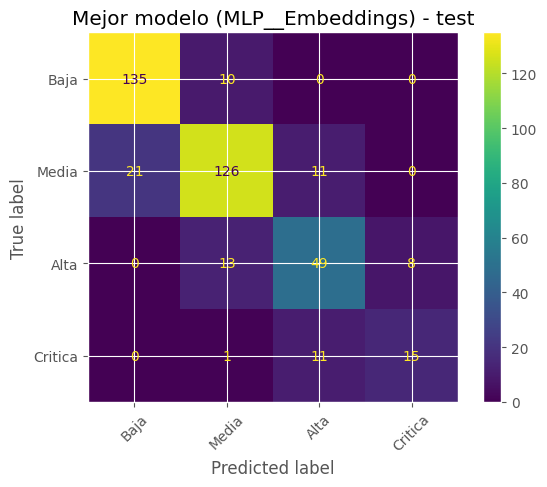

In [24]:
# Recuperamos el run de refit del mejor modelo (su pipeline ya entrenada con train+val).
mejor_refit = runs[(runs["tags.stage"] == "refit_final") & (runs["tags.study_name"] == mejor["study_name"])].iloc[0]
mejor_modelo = mlflow.sklearn.load_model(f"runs:/{mejor_refit['run_id']}/model")

# Evaluación FINAL en test del modelo elegido.
pred_test = mejor_modelo.predict(X_test)
print("Macro recall (test):", round(recall_score(y_test, pred_test, average="macro"), 3))
print(classification_report(y_test, pred_test))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=ORDEN_CLASES, xticks_rotation=45)
plt.title(f"Mejor modelo ({mejor['study_name']}) - test")
plt.show()

Guarda ahora el modelo para utilizarlo en la siguiente fase

In [25]:
import cloudpickle

# El pipeline elegido contiene un tokenizador propio (y se cargó "por valor" desde MLflow),
# así que lo serializamos con cloudpickle para que el artefacto quede autocontenido y portable.
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(mejor_modelo, f)

with mlflow.start_run(run_name=f"modelo_final_{mejor['study_name']}"):
    mlflow.set_tag("stage", "modelo_final")
    mlflow.log_param("modelo_elegido", mejor["study_name"])
    mlflow.log_metric("macro_recall_test", float(recall_score(y_test, pred_test, average="macro")))
    # cloudpickle evita el serializador estricto (skops) que rechaza el tokenizador propio
    mlflow.sklearn.log_model(mejor_modelo, name="modelo_final", serialization_format="cloudpickle")
print("Modelo exportado a modelo_final.pkl")

2026/07/06 22:43:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo exportado a modelo_final.pkl


Responde:

1. ¿Por qué el conjunto de **test** se lee recién al final y la selección se hace por `macro_recall_val`? **(0.2 pts)**
2. Además de la métrica, ¿qué otros criterios considerarías para elegir el modelo de **producción**? En particular: si el mejor modelo usa **embeddings**, ¿qué implica eso en inferencia (pista: hay que llamar a la API de `gemini-embedding-001`)? **(0.2 pts)**
3. Mira el desempeño **por clase** en test, especialmente `Critica`. ¿El modelo sirve para el objetivo de negocio (priorizar bien los tickets críticos)? **(0.2 pts)**
4. ¿Qué información registrarías en MLflow para que este modelo sea **reproducible y desplegable** por otra persona del equipo? **(0.2 pts)**
5. Mirando todo el barrido, ¿el mejor modelo justifica su complejidad frente a alternativas más simples? ¿Cuál llevarías tú a producción y por qué? **(0.2 pts)**

_Subtotal preguntas: 1.0 pts_

**Responde aquí**

> 

1- El conjunto de **test** se reserva hasta el final porque debe representar datos completamente nuevos, no usados para entrenar ni para tomar decisiones. Si miráramos el test durante la búsqueda de modelos o hiperparámetros, podríamos terminar eligiendo el modelo que mejor funciona en ese test por casualidad, y la métrica dejaría de ser una estimación honesta del desempeño real.

Por eso la selección se hace usando `macro_recall_val`: el conjunto de validación sirve justamente para comparar modelos, ajustar hiperparámetros y decidir cuál configuración usar. En este caso, se elige el modelo con mejor desempeño en validación, no necesariamente el que tiene mejor resultado en test.

El test se usa recién después de elegir el modelo para obtener una evaluación final independiente. Así podemos saber si el modelo generaliza bien o si estaba sobreajustado a validación. Por ejemplo, `MLP__Embeddings` tuvo el mejor `macro_recall_val`, por eso se selecciona, aunque en test queda levemente por debajo de `Regresión_Logística__Embeddings`. Esa diferencia muestra precisamente por qué el test no debe usarse para escoger el modelo.

2- Además de la métrica, consideraría criterios de producción como **costo de inferencia**, **latencia**, **simplicidad del pipeline**, **robustez**, **mantenibilidad**, **dependencias externas** e **interpretabilidad**. Un modelo con una métrica levemente superior no siempre es el mejor para producción si requiere más infraestructura, es más lento o depende de servicios externos.

Si el mejor modelo usa **embeddings**, entonces en inferencia no basta con pasar el ticket directamente al clasificador. Primero hay que construir el texto del ticket, llamar a la API de `gemini-embedding-001`, obtener el vector de 1024 dimensiones y recién después entregar ese vector al pipeline/modelo. Esto implica mayor **latencia**, porque cada predicción depende de una llamada externa, y también mayor **costo**, porque cada ticket requiere consumir la API de embeddings.

También aparece una dependencia operacional importante: si la API falla, cambia, se vuelve más lenta o se agota la cuota, el sistema de priorización podría degradarse o dejar de funcionar. Además, habría que controlar versionamiento del modelo de embeddings, monitorear drift, guardar logs y posiblemente cachear embeddings para no recalcularlos innecesariamente.

Por eso, aunque `MLP__Embeddings` sea el mejor según `macro_recall_val`, para producción compararía su ganancia real contra alternativas más simples como `Regresión_Logística__Base+Bow`. Esta última puede ser un poco peor en métrica, pero es más barata y autónoma porque no requiere llamar a una API externa para generar embeddings en cada inferencia.

3- El modelo tiene un desempeño **razonable**, pero no completamente satisfactorio para el objetivo de negocio si la prioridad principal es detectar todos los tickets `Critica`. En test, para la clase `Critica` obtiene un **recall de 0.56**, es decir, detecta correctamente solo 15 de los 27 tickets críticos. Esto implica que alrededor del 44% de los casos críticos no fueron clasificados como `Critica`, lo cual es riesgoso en un contexto fintech.

Sin embargo, al mirar la matriz de confusión, la mayoría de los errores de `Critica` no caen en clases bajas: 11 tickets críticos fueron predichos como `Alta`, solo 1 como `Media` y ninguno como `Baja`. Esto es importante, porque si operacionalmente `Alta` también recibe atención rápida, el daño de esos errores podría ser menor. El modelo no está ignorando los casos críticos, sino que muchas veces los baja un nivel de urgencia.

Aun así, para producción no lo consideraría suficiente si el negocio necesita distinguir con alta seguridad los tickets verdaderamente críticos. Usaría este modelo como apoyo inicial, pero agregaría medidas como revisión humana de casos `Alta` y `Critica`, ajuste de umbrales para favorecer recall en `Critica`, oversampling de la clase crítica o una métrica de selección más enfocada en `recall_test_Critica`. En resumen, el modelo sirve como base de priorización, pero todavía requiere mejoras o reglas adicionales para cumplir bien el objetivo de detectar tickets críticos.

4- Para que el modelo sea reproducible, registraría en MLflow todos los elementos necesarios para reconstruir exactamente el experimento: nombre del modelo, feature-set usado, hiperparámetros óptimos, semilla aleatoria, métrica de selección (`macro_recall_val`), métricas finales en test y métricas por clase, especialmente `recall`, `precision` y `f1` de `Critica`.

También registraría el pipeline completo, no solo el clasificador. Esto incluye el preprocesamiento usado antes del modelo: selección de columnas, `StandardScaler`, `OneHotEncoder`, `CountVectorizer`, tokenizador con stemming, stopwords, y en caso de embeddings, la versión del modelo externo usado para generarlos, por ejemplo `gemini-embedding-001`. Esto es clave porque otra persona debe poder aplicar exactamente las mismas transformaciones en inferencia.

Además, guardaría artefactos de evaluación como el `classification_report`, la matriz de confusión, permutation importance y gráficos comparativos entre modelos. Estos artefactos permiten entender no solo cuál modelo ganó, sino también en qué clases falla, especialmente si confunde `Critica` con `Alta` o `Media`.

Para hacerlo desplegable, registraría el modelo final entrenado con `train+val`, su `run_id`, el ambiente de ejecución o dependencias (`requirements.txt` o ambiente con versiones de `scikit-learn`, `lightgbm`, `mlflow`, etc.), y un ejemplo de entrada/salida del modelo. Si el modelo usa embeddings, también documentaría que antes de predecir hay que llamar a la API de embeddings, cómo construir el texto de entrada y qué dimensión debe tener el vector resultante.

En resumen, MLflow debería guardar no solo la métrica final, sino también el pipeline, hiperparámetros, datos usados, artefactos de evaluación, dependencias y supuestos de inferencia. Así otra persona del equipo podría cargar el modelo, reproducir la evaluación y desplegarlo sin depender de detalles implícitos del notebook.

5- Mirando todo el barrido, el mejor modelo según validación fue `MLP__Embeddings`, pero no creo que su complejidad se justifique completamente frente a alternativas más simples. Aunque obtuvo el mayor `macro_recall_val`, en test quedó con un `macro_recall_test` cercano a **0.746**, muy parecido e incluso levemente inferior a `Regresión_Logística__Embeddings`, que obtuvo cerca de **0.751**. Además, la MLP tiene más hiperparámetros, mayor costo computacional y mostró señales de posible sobreajuste.

Yo llevaría a producción **`Regresión_Logística__Embeddings`**, siempre que el costo y la latencia de generar embeddings con `gemini-embedding-001` sean aceptables. La elegiría porque tiene un desempeño muy competitivo, mejor recall en `Critica` que la MLP, y es bastante más simple, estable y fácil de mantener que una red neuronal.

Si el sistema necesitara ser más barato, rápido y sin depender de una API externa, consideraría como alternativa **`Regresión_Logística__Base+Bow`**. Su desempeño es apenas menor, con `macro_recall_test` cercano a **0.743**, pero evita el costo operacional de generar embeddings en inferencia.

En resumen, no elegiría la MLP solo por haber ganado en validación. Para producción priorizaría un modelo más simple y robusto: **Regresión Logística con embeddings** si se acepta la dependencia externa, o **Regresión Logística con Base+Bow** si se busca una solución más autónoma y barata.